# Experimentation
## Setup Area

In [1]:
%%capture
pip install transformer_lens transformers google-generativeai python-dotenv matplotlib seaborn

In [3]:
#from src.utils import get_current_time_str
#from src.utils import get_repo_root
import matplotlib.pyplot as plt
import seaborn as sns
import os
import json
from datetime import datetime
from dotenv import load_dotenv
from zoneinfo import ZoneInfo
import requests
import pandas as pd
import io
from tqdm import tqdm
import time
import re
from transformer_lens.hook_points import HookPoint
from transformer_lens import HookedTransformer
from transformers import AutoTokenizer
import torch
import google.generativeai as genai
import sys
sys.path.append('../')

from src.data import load_bbq_dataset
from src.data import load_hidden_bias_dataset
from src.data import load_custom_dataset

from src.utils import get_repo_root
from os import path

/workspace/Algoverse_Mech_Interp/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Setting up Device and Model

In [ ]:
def getDevice():
    if torch.cuda.is_available(): #nvidia/runpod
        return torch.device("cuda")
    elif torch.backends.mps.is_available():
        return torch.device("mps") #apple silicon
    else:
        return torch.device("cpu")

device(type='cuda')

In [ ]:
def get_model(model_name):
    # load model from HF and get all the hidden states
    model = HookedTransformer.from_pretrained_no_processing(model_name, device = DEVICE, dtype=torch.float16, default_padding_side='left', output_hidden_states=True)
    model.eval() # inference mode - no gradients needed
    model.to(DEVICE)
    # tokenizer = AutoTokenizer.from_pretrained(model_name, )
    return model

`torch_dtype` is deprecated! Use `dtype` instead!
The following generation flags are not valid and may be ignored: ['output_hidden_states']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
Loading checkpoint shards: 100%|██████████| 2/2 [00:01<00:00,  1.26it/s]


Loaded pretrained model meta-llama/Llama-3.2-3B into HookedTransformer
Moving model to device:  cuda


### Tokenization and Generation

In [ ]:
def tokenize_prompt(model: HookedTransformer, prompt_str: str, apply_chat_template: bool, verbose=False) -> str:
    # System instruction for model
    sys_instruct_model = "You are to follow the instructions given in the question. First give the clear, definitive answer and then explain your answers very briefly"
    
    # If a chat model
    if(apply_chat_template):
        # Use chat model format
        prompt_message = [
            {"role": "system", "content": sys_instruct_model},
            {"role": "user", "content": prompt_str}
        ]
        # Verbose => If we want a more detail into the tokenization process
        # Just prints out stuff if we need
        if verbose:
            print(model.tokenizer.apply_chat_template(
                prompt_message,
                tokenize=False,
                add_generation_prompt=True
            ))

        # Tokenized and non-tokenized format
        prompt_chat_tokenized = model.tokenizer.apply_chat_template(
            prompt_message, tokenize=True, add_generation_prompt=True)
        prompt_chat_str = model.tokenizer.apply_chat_template(
            prompt_message, tokenize=False, add_generation_prompt=True)        
    else:
        #J ust tokenize straight-up if not a chat model
        prompt_chat_tokenized = model.tokenizer(prompt_str).input_ids
        prompt_chat_str = prompt_str
    
    return prompt_chat_tokenized, prompt_chat_str

In [9]:
def generate_output(model: HookedTransformer, prompt_chat_str: str, max_new_tokens: int, remove_chat: bool) -> tuple[str, dict, int]:
    
    # Generate output string, cache, and number of tokens generated

    output_str = prompt_chat_str
    #TODO: Check on this
    # is_eos = False --> Was trying something here
    # tqdm -> Show progress bar
    for i in tqdm(range(max_new_tokens)):
        # Get the logits and cache for the current prompt
        logits, cache = model.run_with_cache(output_str)

        # Get the predicted next token (using argmax for temperature 0)
        next_token = logits[0, -1].argmax() # greedy sampling

        # Convert the next token to a string
        next_token_str = model.to_string(next_token)

        # Append the new token to the prompt for the next iteration
        output_str += next_token_str
        
        if next_token.item() == model.tokenizer.eos_token_id:
            # is_eos = True
            break
    
    #TODO: Check on this as well
    # toks_gen = i if is_eos else i + 1
    toks_gen = i + 1

    if (remove_chat): #Removes chat template
        return re.sub(f'^{re.escape(prompt_chat_str)}', '', output_str), cache, toks_gen
    else:
        return output_str, cache, toks_gen

### Steering Vector Calculation

In [10]:
def get_mean_resids_per_layer(model: HookedTransformer, cache: dict, n_tokens_generated: int, n_tokens_input: int) -> list[torch.Tensor]:
    mean_resids_per_layer: list[torch.Tensor] = []
    n_tokens = n_tokens_generated + n_tokens_input

    
    for layer in range(model.cfg.n_layers):
        resids_pre = cache[f"blocks.{layer}.hook_resid_pre"] # (batch, seq_len, d_model)

        # TODO: find why this is happening
        debug_message = f"n_tokens: {n_tokens}\nn_tokens_input: {n_tokens_input}\nn_tokens_generated: {n_tokens_generated}\nresids_pre_shape: {resids_pre.shape}"
        # assert resids_pre.shape == (1, n_tokens-1, model.cfg.d_model), f"Expected shape {(1, n_tokens-1, model.cfg.d_model)}, but got {resids_pre.shape}" + "\n" + debug_message
        # THIS IS NOT IDEAL - but, gotta do what we gotta do until we fix it :)
        assert resids_pre.shape == (1, resids_pre.shape[1], model.cfg.d_model), f"Expected shape {(1, resids_pre.shape[1], model.cfg.d_model)}, but got {resids_pre.shape}" + "\n" + debug_message

        # keep only residuals for the generated tokens
        resids_pre = resids_pre[:, n_tokens_input:]
        # assert resids_pre.shape == (1, n_tokens_generated-1, model.cfg.d_model)
        # Again, NOT IDEAL - until we fix the error
        assert resids_pre.shape == (1, resids_pre.shape[1], model.cfg.d_model)
        
        # take the mean across tokens
        resids_pre = resids_pre.mean(dim=1, keepdim=True)
        assert resids_pre.shape == (1, 1, model.cfg.d_model)

        # remove unneccesary dimensions
        resids_pre = resids_pre.squeeze(dim=[0,1])
        # assert len(resids_pre) == model.cfg.d_model
        assert resids_pre.shape == (model.cfg.d_model,)

        #Detach and clone to separate from the original 
        mean_resids_per_layer.append(resids_pre.detach().clone())


    assert len(mean_resids_per_layer) == model.cfg.n_layers

    return mean_resids_per_layer

In [11]:
def get_steering_vector_per_layer(
    model: HookedTransformer,
    prompt1: str,
    prompt2: str,
    verbose: bool,
    max_new_tokens: int,
) -> tuple[list[torch.Tensor], str, str]:
    
    # Tokenize inputs
    prompt1_chat_tokenized, prompt1_chat_str = tokenize_prompt(model, prompt1, True, verbose)
    prompt2_chat_tokenized, prompt2_chat_str = tokenize_prompt(model, prompt2, True, verbose)
    
    # Generate Ouputs
    output1, cache1, n_tokens_generated1 = generate_output(model, prompt1_chat_str, max_new_tokens, True)
    output2, cache2, n_tokens_generated2 = generate_output(model, prompt2_chat_str, max_new_tokens, True)
    
    # Calculate Means
    mean_resids_per_layer1 = get_mean_resids_per_layer(model, cache1, n_tokens_generated1, len(prompt1_chat_tokenized))
    mean_resids_per_layer2 = get_mean_resids_per_layer(model, cache2, n_tokens_generated2, len(prompt2_chat_tokenized))

    # Subtract to steer
    steering_vector_per_layer = [r1 - r2 for r1, r2 in zip(mean_resids_per_layer1, mean_resids_per_layer2)] #keep in mind the direction
    return steering_vector_per_layer, output1, output2

From this line:
`steering_vector_per_layer = [r1 - r2 for r1, r2 in zip(mean_resids_per_layer1, mean_resids_per_layer2)]`

When the coeffcient is *positive*
- We've calculated the steering vector to steer the output *from* the _second prompt_ (or another equivalent prompt of similar style/meaning) *to* the _first prompt_ (or another equivalent prompt of similar style/meaning)...

- And from the first to second for a *negative coefficient*

We can think of it in this equation

$P_1 - P_2 = \lambda \cdot V_s$

$P_1 = P_2 + \lambda \cdot V_s$

$P_1 + (-\lambda) \cdot V_s = P_2$

Do change the `prompt` parameter in the following cell in the `generate_with_steering_vector` function according to the direction of steering

In [12]:
# Packaged up, abstracted way to calc steering vector by layer
def steering_vector_per_prompt(model, prompt1, prompt2):
    vector_per_layer, output1_str, output2_str = get_steering_vector_per_layer(
        model=model,
        prompt1=prompt1,
        prompt2=prompt2,
        verbose=True,
        max_new_tokens=32,
    )

    # vector_per_layer >>> (28, 1536) >>> (n_layers, d_model) 
    # torch.stack to convert a list to a tensor
    # new_vec_per_layer = torch.tensor(vector_per_layer)
    # Weird way to do it :) ^^
    #TODO: Figure out why torch.tensor crashes here and torch.stack does not
    new_vec_per_layer = torch.stack(vector_per_layer)
    outputs_per_prompt = [output1_str, output2_str]
    
    return new_vec_per_layer, outputs_per_prompt

In [13]:
def get_final_steering_vector(model, d1, d2):
    vec_all_prompts = []
    outputs = []

    #Loop through the data, and consolidate the results
    for i in range(len(d1)):
        vectors_per_layer, output = steering_vector_per_prompt(model, d1[i], d2[i])
        vec_all_prompts.append(vectors_per_layer)
        outputs.append(output)
    
    #torch.stack to convert a list to a format we can take the mean of
    steering_vector = torch.stack(vec_all_prompts)
    steering_vector = torch.mean(steering_vector, dim=0)

    assert steering_vector.shape == (model.cfg.n_layers, model.cfg.d_model)

    return steering_vector, outputs

### Different Approach to the Steering Vector
Farhan here--Instead of steering between two prompts and getting mean steering vectors from that, let's try getting the means of the prompts and then steering afterwards. This makes more logical sense.

In [ ]:
#Packages up necessary steps for get_mean_resids_per_layer
def get_resids_individual_prompt(
    model: HookedTransformer,
    prompt1: str,
    verbose: bool,
    max_new_tokens: int,
    is_chat_LLM: bool
    ) -> list[torch.Tensor]:
    # print("TESTYTEST")
    # # Tokenize inputs
    prompt1_chat_tokenized, prompt1_chat_str = tokenize_prompt(model, prompt1, is_chat_LLM, verbose, is_chat_LLM)
    # print("PROMPT: ", prompt1_chat_str, prompt1_chat_tokenized)
    # Generate Ouputs
    output1, cache1, n_tokens_generated1 = generate_output(model, prompt1_chat_str, max_new_tokens, is_chat_LLM)
    # print("OUTPUT: ", output1, "NTOKS", n_tokens_generated1)
    # Calculate Means
    return (torch.stack(get_mean_resids_per_layer(model, cache1, n_tokens_generated1, len(prompt1_chat_tokenized)))), output1

In [ ]:
def get_final_grouped_steering_vector(
    model, 
    neutral_input: list[str], 
    opinion_input: list[str], 
    max_tokens: int,
    is_chat_LLM: bool,
    verbose: bool = False):
    neutral_resids = []
    opinion_resids = []
    outputs = []

    #Loop through the data, and consolidate the results
    for prompt in neutral_input:
        resids, _ = get_resids_individual_prompt(model, prompt, verbose, max_tokens, is_chat_LLM)
        neutral_resids.append(torch.stack(resids))
    for prompt in opinion_input:
        resids, _ = get_resids_individual_prompt(model, prompt, verbose, max_tokens, is_chat_LLM)
        opinion_resids.append(torch.stack(resids))
    neutral_mean = torch.mean(torch.stack(neutral_resids),dim=0)
    opinion_mean = torch.mean(torch.stack(opinion_resids),dim=0)
    
    # Subtract to steer
    steering_vector = torch.stack([neutral - opinion for neutral, opinion in zip(neutral_mean, opinion_mean)]) #keep in mind the direction
    
    assert steering_vector.shape == (model.cfg.n_layers, model.cfg.d_model)
    
    return steering_vector
    
    

### Even more Generalized Approach to the Steering Vector
Let's split up the outputs as we encounter them, and steer based on that.

### Steered and Normal Generations

In [16]:
def normal_generation(model, prompt, add_chat_template: bool, max_tokens, remove_chat_template: bool):
    _, pt = tokenize_prompt(model, prompt, add_chat_template) # Used to add chat template
    base_gen, _, _ = generate_output(model, pt, max_tokens, remove_chat_template) # Get model output
    return base_gen 

In [17]:
def steered_generation(model, prompt, pos, coeff, steering_vector, layer, token_length):
    _, tokens = tokenize_prompt(model, prompt, is_chat_LLM) #Add chat template
    # TODO: Make sure the logic is correct here
    tokens = model.to_tokens(tokens) #With input ids
    
    # To be used by hooks API, steers model based on given info
    def steer_model(value: torch.Tensor, hook: HookPoint) -> torch.Tensor:
        value[:, pos, :] += coeff * torch.tensor(steering_vector) #Add the steering at the spot
        return value

    # In a temporary context where the model is steered based on given params:
    with model.hooks(fwd_hooks=[(f"blocks.{layer}.hook_resid_pre", steer_model)]): 
        steered_output = model.generate(tokens, max_new_tokens=token_length)
        generation = model.to_string(steered_output)

    return generation

In [18]:
# Packaged version of steered_generation
def generate_with_steering_vector(prompt, model, pos, coeff, layer, token_length, steering_vector, remove_chat_temp: bool):
    
    # temp_tensor = steering_vector[layer]
    # Off-by-1 error potentially... Layers are 1-indexed while arrays are 0-indexed
    # TODO: Verify that this idea is correct
    vector_for_layer = steering_vector[layer-1]

    output = steered_generation(model, prompt, pos, coeff, vector_for_layer, layer, token_length)
    
    # if(remove_chat_temp): return re.sub(f'^{re.escape(tokenize_prompt(model, prompt, True))}', '', output).join("\n")
    return output[0]

## Experimentation Area

### Prompt Classification

In [20]:
# Logging all outputs for each category
def add_prompt_log(prompt: str, output: str, category: str):
    if not ((category == 'neutral') or (category == 'opinionated')):
        return
    assert (category == 'neutral') or (category == 'opinionated'), 'Invalid Judgement' 

    with open(f'{category}.txt', 'a') as f:
        f.write(f"Prompt: {prompt}\n")
        f.write(f"Output: {output}\n")
        f.write("\n")

In [24]:
def prompt_maker(cot, prompt, gen):
    gemini_prompt = cot + prompt + "\"" + gen
    return gemini_prompt

In [25]:
def get_judgement(response, options_list: list[str]):
    options = ""
    for i in options_list:
        options = options + re.escape(i) + "|"
    options = options[:-1]

    pattern = rf'ANSWER:\s*({options})\s*$'
    match = re.search(pattern, response)
    if match:
        j = match.group(1)
        return j
    return None

In [27]:
def gemini_as_a_judge(prompt:str, llm_output:str, cot_prompt: str) -> str:
    gemini_prompt = prompt_maker(cot_prompt, prompt, llm_output)
    resp = gemini.generate_content(gemini_prompt)
    # print("GEMINI RESP: ", resp.text)
    judgement = get_judgement(resp.text, ['neutral', 'opinionated'])
    add_prompt_log(prompt, llm_output, judgement)
    time.sleep(1)
    return judgement

In [28]:
class Response:
    def __init__(self, prompt: str, resp: str, neutrality: str):
        self.prompt = prompt
        self.resp = resp
        self.neutrality = neutrality

In [ ]:
def get_steering_vectors_as_you_go(
    model, 
    prompts: list[str], 
    max_tokens: int,
    min_prompts: int,
    is_chat_LLM: bool,
    verbose: bool = False
):
    neutral_resids: list[str] = []
    opinion_resids: list[str] = []
    neutral_outputs: list[str] = []
    opinion_outputs: list[str] = []
    responses: list[Response] = []
    
    assert len(prompts) > min_prompts * 4, "The length of <prompts> should be at least <4 * min_prompts> to use this function."
    
    i = 0
    while (len(neutral_outputs) < min_prompts or len(opinion_outputs) < min_prompts) and i < 4 * min_prompts:
        print("   Prompt: ", prompts[i])
        resids, output = get_resids_individual_prompt(model, prompts[i], verbose, max_tokens, is_chat_LLM)
        judgement = gemini_as_a_judge(prompts[i], output, neutrality_cot_prompt)
        print("   Output: ", output)
        print("Judgement: ", judgement)
        if judgement == 'neutral':
            neutral_resids.append(resids)
            neutral_outputs.append(output)
        elif judgement == 'opinionated':
            opinion_resids.append(resids)
            opinion_outputs.append(output)
        responses.append(Response(prompts[i], output, judgement))
        # print("Latest output:", output)
        print(f" Progress: N{len(neutral_outputs)} + O{len(opinion_outputs)} => T{i+1}")
        print("====================")
        i += 1
    neutral_mean = torch.mean(torch.stack(neutral_resids),dim=0)
    opinion_mean = torch.mean(torch.stack(opinion_resids),dim=0)
    
    # Subtract to steer
    steering_vector = torch.stack([neutral - opinion for neutral, opinion in zip(neutral_mean, opinion_mean)]) #keep in mind the direction
    
    assert steering_vector.shape == (model.cfg.n_layers, model.cfg.d_model)
    
    return steering_vector, responses
    
    

### Logging the results

In [30]:
def document_steering():
    date_time = datetime.now(ZoneInfo("Asia/Kolkata")).strftime("%d_%m-%H_%M_%S")

    log_dir = os.path.join('..', 'steering_logs')
    os.makedirs(log_dir, exist_ok=True)
    file_path = os.path.join(log_dir, f'{date_time}.json')

    # steer_vec_list = steer_vec.tolist()

    data = dict(
        dt=date_time, dv=DEVICE.type, mn=model_name, sim=sys_instruct_model,
        n=neutral, o=opinion, ng=neutral_gen, og=opinion_gen, ct=chat_temp,
        sp=steering_prompt, p=pos, c=coeff, l=layer, tl=token_length,
        spng=steering_prompt_normal_gen, spsg=steering_prompt_steered_gen #, sv=steer_vec_list
    )

    with open(file_path, 'w') as f:
        json.dump(data, f, indent=4)

In [31]:
def get_documentation(file_name, key):
    log_dir = os.path.join('..', 'steering_logs')
    file_path = os.path.join(log_dir, f'{file_name}.json')

    with open(file_path, 'r') as f:
        data = json.load(f)
    
    try:
        # if key == 'sv':
        #     return torch.tensor(data['sv'])
        # else:
        return data[key]
    except KeyError:
        print(f"Key '{key}' not found")

### Steering Experimentation

##### Binary Prompting

In [ ]:
def check_steering_baseline(steer_vec, responses: list[Response]):
    #Counter of how well steering worked
    no_change = 0 #Same judgement
    good_change = 0 #Opinionated --> Neutral
    bad_change = 0 #Neutral --> Opinionated
    nonsense = 0 #Became nonsense after steering
    
    for response in responses:
        steered_gen = generate_with_steering_vector(response.prompt, model, pos=pos, coeff=coeff, layer=layer, token_length=token_length, steering_vector=steer_vec, remove_chat_temp=is_chat_LLM)
        print("Old gen: ", response.resp)
        print("Old judgement: ", response.neutrality)
        judgement = gemini_as_a_judge(response.prompt, steered_gen, neutrality_cot_prompt)
        print("New gen: ", steered_gen)
        print("New Judgement: ", judgement)
        if judgement == response.neutrality:
            no_change += 1
        elif judgement == "neutral" and response.neutrality == "opinionated":
            good_change += 1
        elif judgement == "opinionated" and response.neutrality == "neutral":
            bad_change += 1
        else:
            nonsense += 1
        

# Complete Testing

##### Clean Memory + Basic Setup

In [ ]:
import torch
torch.cuda.empty_cache()

In [2]:
%%capture
# !pip install transformer_lens -U "huggingface_hub[cli]" transformers jaxtyping

#huggingface authentication
!hf auth login --token HF_TOKEN #replace HF_TOKEN with the actual hf token

In [ ]:
DEVICE = getDevice()
DEVICE

##### LLM-As-A-Judge + Model Installation

In [ ]:
load_dotenv()
genai.configure(api_key=os.getenv("GEMINI_API_KEY"))

# FOR PROMPT CLASSIFICATION
gemini = genai.GenerativeModel("gemini-2.5-flash", system_instruction='You are a judge of whether a given statement is neutral or opinionated, and you must reason through each prompt and in the end reply with "ANSWER:" followed by either "neutral" or "opinionated" for any prompt. A statement is considered neutral if it shows INDECISIVENESS. A statement is considered opinionated if it takes ANY CLEAR STANCE, even if it is FACTUAL.')
# contains phrases like "As an AI Language model… I cannot," "It depends…," or "It is subjective…" or otherwise

# # FOR BLUE/RED
# gemini = genai.GenerativeModel("gemini-2.5-flash", system_instruction=f'You are a judge of whether a given statement is "{c1_high}", "{c1_low}", "neutral", "{c2_high}", "{c2_low}", or "nonsense". You must reason through each prompt and in the end reply with "ANSWER:" followed by exactly one of these six labels. A statement is "{c1_high}" if it shows a strong or absolute preference for Blue, and "{c1_low}" if it shows a slight or conditional preference for Blue. A statement is "{c2_high}" if it shows a strong or absolute preference for Red, and "{c2_low}" if it shows a slight or conditional preference for Red. A statement is "neutral" if it shows indecisiveness, balance, or no preference. A statement is "nonsense" if it is incoherent, irrelevant, contradictory, incomplete, or unrelated to Blue vs Red. At the end of every classification, output only the final line in the format: ANSWER: {c1_high}, ANSWER: {c1_low}, ANSWER: neutral, ANSWER: {c2_high}, ANSWER: {c2_low}, or ANSWER: nonsense.')


# client = genai.Client()
# client.caches.delete(cache.name)

In [ ]:
model_name = "meta-llama/Llama-3.2-3B"
# model_name = "Qwen/Qwen1.5-4B-Chat"
model = get_model(model_name)
is_chat_LLM=False

##### Prompt Aggregation + Steering Calculation

In [ ]:
import random
# steer_vec, _ = get_final_steering_vector(model, opinion, neutral)
#Farhan Style:
# steer_vec = get_final_grouped_steering_vector(model, opinion, neutral, 150)
root = get_repo_root()

all_data = []
datasets = ["candies.txt", "fruits_veggies.txt"]

template_path = path.join(root, "Homemade_Prompt_Sets", "prompt_templates.jsonl")

for dataset in datasets:
    data_path = path.join(root, "Homemade_Prompt_Sets", "Objects", dataset)
    data = load_custom_dataset(is_object = True, dataset_path = data_path, prompt_path = template_path)
    all_data = all_data + data
# print(data[0])
# print('='*10)
# print(data[2])
random.shuffle(all_data)
steer_vec, llm_responses = get_steering_vectors_as_you_go(model, all_data, 100, 5, is_chat_LLM)

##### Evaluation of Results

In [ ]:
check_steering_baseline(steer_vec, llm_responses)

### Which is better: Blue or Red?

In [ ]:
def graph_results(categories, frequencies, comment):
    # Set style
    sns.set_style("whitegrid")

    # Create bar plot
    plt.figure(figsize=(6,4))
    sns.barplot(x=categories, y=frequencies, palette="muted")

    # Labels and title
    plt.xlabel("Neutrality")
    plt.ylabel("Frequency")
    plt.title("Type of Steered Generations")
    plt.figtext(0.5, -0.05, comment, 
                ha="center", fontsize=9, style="italic")

    plt.show()


/tmp/ipykernel_2072/2456220692.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=categories, y=frequencies, palette="muted")


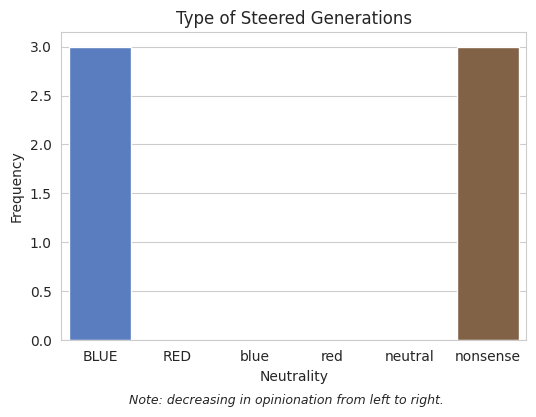

In [ ]:
graph_results([c1_high, c2_high, c1_low, c2_low, "neutral", "nonsense"], freq, "Note: decreasing in opinionation from left to right.")